In [5]:
!pip install nltk

In [6]:
import numpy as np
import pandas as pd
import re
import nltk

In [7]:
df=pd.read_json("hr_interview_questions_dataset.json",orient="records")

In [ ]:
print(df['experience'].value_counts())

experience
fresher     278215
7+ years    278100
intern      278052
3 years     277953
6 years     277718
2 years     277643
1 year      277623
5 years     277546
4 years     277150
Name: count, dtype: int64


In [5]:
reduced_df=df.groupby('role').sample(
    n=6000,
    random_state=42
    )

In [6]:
reduced_df=reduced_df.sample(
    frac=1,
    random_state=42
)

In [7]:
reduced_df.head()

,question,category,role,experience,difficulty,source_type,ideal_answer,keywords
1180194,Describe a project where teamwork was essentia...,Team Collaboration,QA Analyst,1 year,Easy,Behavioral,I believe communication and mutual respect are...,"[partner, group]"
1309311,What type of company culture do you thrive in?,Culture Fit,Software Engineer,1 year,Medium,Situational,"I thrive in collaborative, transparent environ...","[belief, environment]"
518341,How do you ensure productivity when working re...,Work Style,UX Designer,fresher,Hard,Situational,I follow a structured workflow and use tools l...,"[tool, method]"
1382750,Describe a time you failed and what you learne...,Adaptability,Data Scientist,2 years,Hard,Behavioral,I'm always eager to learn and embrace change a...,"[new, learn]"
1600759,What kind of growth opportunities are you look...,Career Goals,Data Scientist,2 years,Easy,STAR-Based,My long-term goal is to grow into a senior rol...,"[next step, aspiration]"


In [8]:
reduced_df.info()

<class 'pandas.DataFrame'>
Index: 48000 entries, 1180194 to 1622082
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   question      48000 non-null  str   
 1   category      48000 non-null  str   
 2   role          48000 non-null  str   
 3   experience    48000 non-null  str   
 4   difficulty    48000 non-null  str   
 5   source_type   48000 non-null  str   
 6   ideal_answer  48000 non-null  str   
 7   keywords      48000 non-null  object
dtypes: object(1), str(7)
memory usage: 15.7+ MB


In [9]:
reduced_df.describe()

,question,category,role,experience,difficulty,source_type,ideal_answer,keywords
count,48000,48000,48000,48000,48000,48000,48000,48000
unique,40,8,8,9,3,4,40,180
top,How do you respond when a teammate isn't pulli...,Adaptability,QA Analyst,3 years,Hard,Situational,"When faced with conflict, I approach it calmly...","[plan, dream]"
freq,1273,6083,6000,5425,16026,12118,1273,335


In [10]:
reduced_df.reset_index(
    drop=True,
    inplace=True
)

In [11]:
reduced_df.shape

(48000, 8)

In [12]:
reduced_df.to_csv(
    "reduced_dataset.csv",
    index=False
)

In [13]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\SUMIT KUMAR
[nltk_data]     JAIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\SUMIT KUMAR
[nltk_data]     JAIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\SUMIT KUMAR
[nltk_data]     JAIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [15]:
reduced_df['keywords']=reduced_df['keywords'].apply(lambda x:str(x))

In [16]:
type(reduced_df['keywords'].iloc[0])

str

In [17]:
reduced_df.drop_duplicates(inplace=True)

In [18]:
for col in reduced_df.columns:
    
    print(col, type(reduced_df[col].iloc[0]))

question <class 'str'>
category <class 'str'>
role <class 'str'>
experience <class 'str'>
difficulty <class 'str'>
source_type <class 'str'>
ideal_answer <class 'str'>
keywords <class 'str'>


In [19]:
reduced_df.dropna(inplace=True)

In [20]:
reduced_df.shape

(46452, 8)

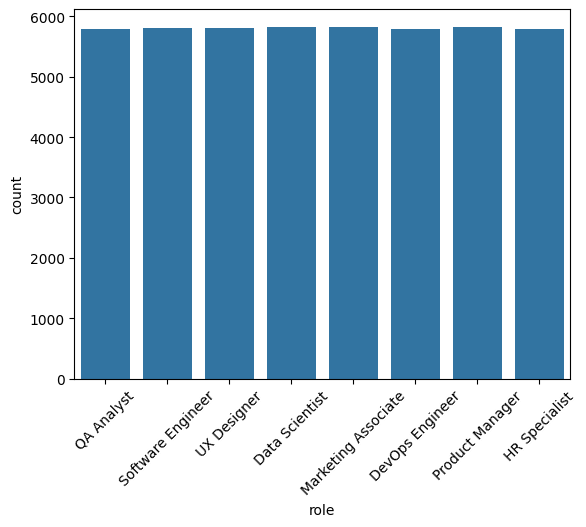

In [21]:
##Exploatory Data Analysis
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=reduced_df['role'])
plt.xticks(rotation=45)
plt.show()


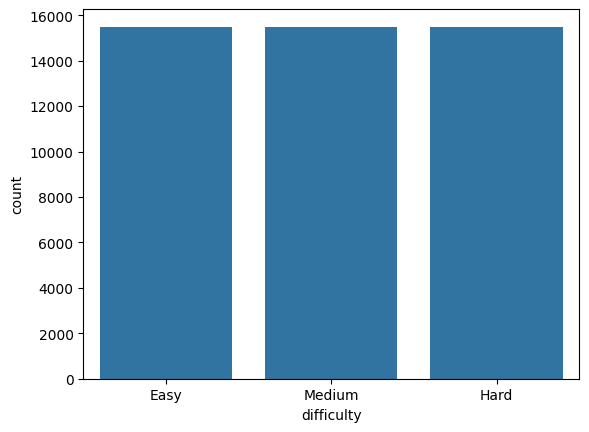

In [22]:
sns.countplot(x=reduced_df['difficulty'])
plt.show()

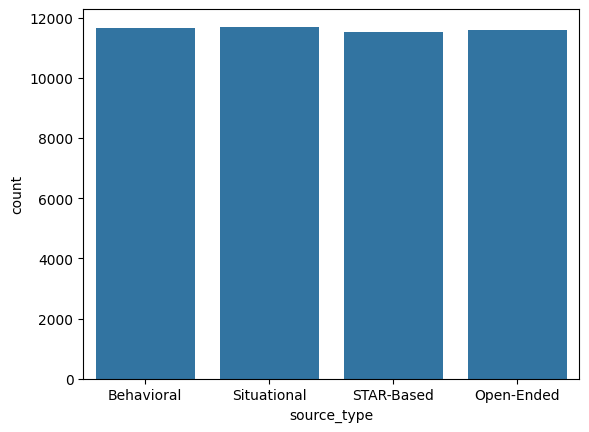

In [23]:
sns.countplot(x=reduced_df['source_type'])
plt.show()

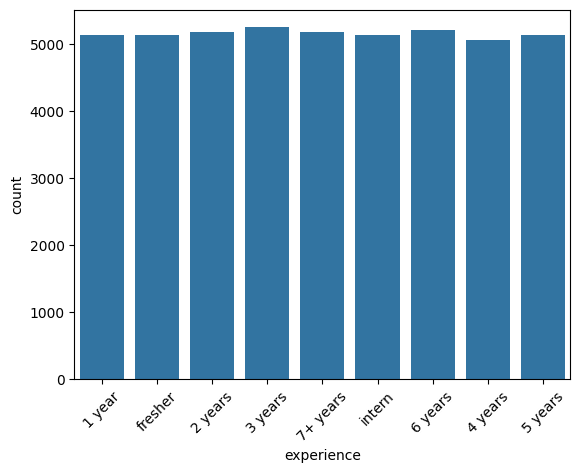

In [24]:
sns.countplot(x=reduced_df['experience'])

plt.xticks(rotation=45)

plt.show()

In [25]:
reduced_df['answer_length']=reduced_df['ideal_answer'].apply(len)

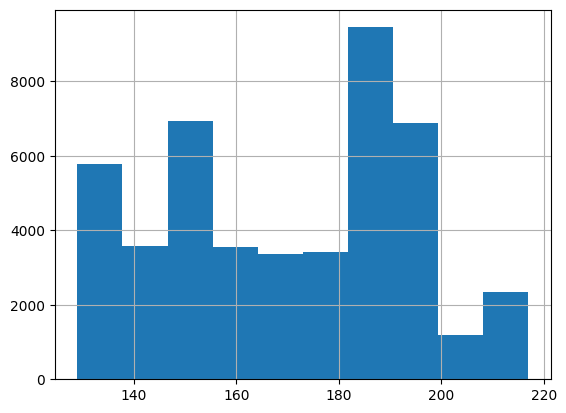

In [26]:
reduced_df['answer_length'].hist()
plt.show()

In [27]:
reduced_df['word_count']=reduced_df['ideal_answer'].apply(
    lambda x: len(str(x).split())
)

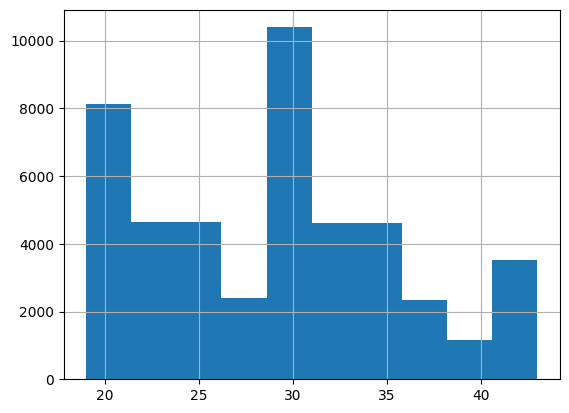

In [28]:
reduced_df['word_count'].hist()
plt.show()

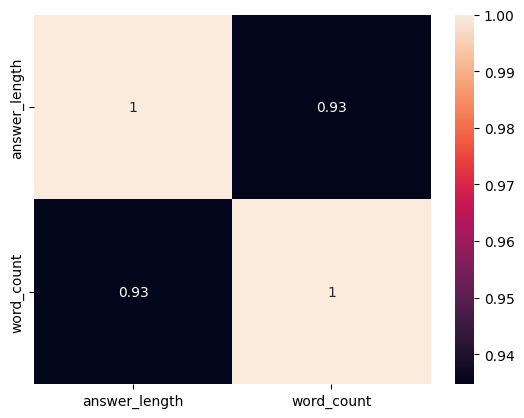

In [29]:
sns.heatmap(
    reduced_df[['answer_length','word_count']].corr(),
    annot=True
    )
plt.show()

In [30]:
lemmatizer=WordNetLemmatizer()
stop_words=set(stopwords.words('english'))


In [31]:
stop_words


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [32]:
reduced_df.head()

,question,category,role,experience,difficulty,source_type,ideal_answer,keywords,answer_length,word_count
0,Describe a project where teamwork was essentia...,Team Collaboration,QA Analyst,1 year,Easy,Behavioral,I believe communication and mutual respect are...,"['partner', 'group']",196,30
1,What type of company culture do you thrive in?,Culture Fit,Software Engineer,1 year,Medium,Situational,"I thrive in collaborative, transparent environ...","['belief', 'environment']",139,21
2,How do you ensure productivity when working re...,Work Style,UX Designer,fresher,Hard,Situational,I follow a structured workflow and use tools l...,"['tool', 'method']",154,23
3,Describe a time you failed and what you learne...,Adaptability,Data Scientist,2 years,Hard,Behavioral,I'm always eager to learn and embrace change a...,"['new', 'learn']",202,41
4,What kind of growth opportunities are you look...,Career Goals,Data Scientist,2 years,Easy,STAR-Based,My long-term goal is to grow into a senior rol...,"['next step', 'aspiration']",199,35


In [33]:
def preprocess_text(text):
    #Lowercase
    text=text.lower()
    
    #Remove punctuation/numbers
    text=re.sub(r'[^a-zA-Z ]','',text)

    #Tokenization
    words=word_tokenize(text)
    cleaned_words=[]

    for word in words:

        #remove stopwards
        if word not in stop_words:

            #Lemmaziation
            word=lemmatizer.lemmatize(word)
            cleaned_words.append(word)
    return " ".join(cleaned_words)
    

In [34]:
reduced_df['cleaned_answer']=reduced_df['ideal_answer'].apply(
        preprocess_text
)

In [35]:
reduced_df.head()

,question,category,role,experience,difficulty,source_type,ideal_answer,keywords,answer_length,word_count,cleaned_answer
0,Describe a project where teamwork was essentia...,Team Collaboration,QA Analyst,1 year,Easy,Behavioral,I believe communication and mutual respect are...,"['partner', 'group']",196,30,believe communication mutual respect key succe...
1,What type of company culture do you thrive in?,Culture Fit,Software Engineer,1 year,Medium,Situational,"I thrive in collaborative, transparent environ...","['belief', 'environment']",139,21,thrive collaborative transparent environment i...
2,How do you ensure productivity when working re...,Work Style,UX Designer,fresher,Hard,Situational,I follow a structured workflow and use tools l...,"['tool', 'method']",154,23,follow structured workflow use tool like jirat...
3,Describe a time you failed and what you learne...,Adaptability,Data Scientist,2 years,Hard,Behavioral,I'm always eager to learn and embrace change a...,"['new', 'learn']",202,41,im always eager learn embrace change way impro...
4,What kind of growth opportunities are you look...,Career Goals,Data Scientist,2 years,Easy,STAR-Based,My long-term goal is to grow into a senior rol...,"['next step', 'aspiration']",199,35,longterm goal grow senior role contribute stra...


In [36]:
!pip install textblob

In [37]:
from textblob import TextBlob

In [38]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

In [39]:
reduced_df['sentiment']=reduced_df['ideal_answer'].apply(
    get_sentiment
)

In [42]:
def keyword_count(keyword_text):
    # keyword_text=keyword_text.replace('[','')
    # keyword_text=keyword_text.replace(']','')
    return len(keyword_text)
    

In [43]:
reduced_df['keyword_count']=df['keywords'].apply(
    keyword_count
)

In [56]:
def create_label(word_count):

    if word_count > 25:
        return "Good"
    elif word_count > 12:
        return "Average"
    else:
        return "Poor"

In [57]:
reduced_df['label'] = reduced_df['word_count'].apply(
    create_label
)

In [58]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(reduced_df['label'])


In [66]:
text_featurre='cleaned_answer'

numeric_feature=[
    'answer_length',
    'word_count',
    'sentiment',
    'keyword_count'
]

categorical_feature=[
    'role',
    'difficulty',
    'category',
    'source_type',
    'experience'
    
]



In [69]:
reduced_df.columns

Index(['question', 'category', 'role', 'experience', 'difficulty',
       'source_type', 'ideal_answer', 'keywords', 'answer_length',
       'word_count', 'cleaned_answer', 'sentiment', 'keyword_count', 'label'],
      dtype='str')

In [48]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

In [70]:
preprocessor=ColumnTransformer(
    transformers=[
        ('text',TfidfVectorizer(max_features=3000),
         'cleaned_answer'),
        
        ('num',StandardScaler(),
         numeric_feature),
        
        ('cat',OneHotEncoder(
            handle_unknown='ignore'),
         categorical_feature)
    ]
)
        

In [52]:
reduced_df.sample(2)

,question,category,role,experience,difficulty,source_type,ideal_answer,keywords,answer_length,word_count,cleaned_answer,sentiment,keyword_count
26630,What are your long-term career aspirations?,Career Goals,Marketing Associate,intern,Hard,Situational,My long-term goal is to grow into a senior rol...,"['plan', 'aspiration']",188,32,longterm goal grow senior role contribute stra...,0.500000,2
24936,How do you contribute to a positive team envir...,Culture Fit,Software Engineer,4 years,Medium,STAR-Based,"I thrive in collaborative, transparent environ...","['culture', 'fit']",146,21,thrive collaborative transparent environment i...,0.227273,2


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])

In [59]:
reduced_df.shape

(46452, 14)

In [63]:
X = reduced_df[[
    'category',
    'role',
    'experience',
    'difficulty',
    'source_type',
    'answer_length',
    'word_count',
    'cleaned_answer',
    'sentiment',
    'keyword_count',  
]]

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [72]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [73]:
prediction=pipeline.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,prediction)
accuracy

1.0

In [82]:
from sklearn.metrics import classification_report
report=classification_report(y_test,prediction)
report

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      3206\n           1       1.00      1.00      1.00      6085\n\n    accuracy                           1.00      9291\n   macro avg       1.00      1.00      1.00      9291\nweighted avg       1.00      1.00      1.00      9291\n'

In [83]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
cm

array([[3206,    0],
       [   0, 6085]])

In [85]:
import pickle
pickle.dump(pipeline,open('interview_model.pkl','wb'))
pickle.dump(label_encoder,open('label_encoder.pkl','wb'))